# Double Responses in Decision Tasks
Group 17

In [1]:
import numpy as np
import bayesflow as bf
import keras

SEED = 2026
N_TRIALS = 1000
MAX_T = 3.0
DT = 0.02
DR_WINDOW = 0.25  # 250ms double-response window, from Evans et al. (2020)

PRIORS = {
    "nu":     {"shape": 5, "scale": 0.5},
    "alpha1": {"shape": 5, "scale": 0.2},
    "tau":    {"scale": 0.15},
}

rng = np.random.default_rng(SEED)

INFO:matplotlib.font_manager:generated new fontManager
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'
/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Priors

In [2]:
def prior():
    nu = rng.gamma(shape=PRIORS["nu"]["shape"], scale=PRIORS["nu"]["scale"], size=2)
    alpha1 = rng.gamma(shape=PRIORS["alpha1"]["shape"], scale=PRIORS["alpha1"]["scale"])
    tau = rng.exponential(scale=PRIORS["tau"]["scale"])
    return {"nu": nu, "alpha1": alpha1, "tau": tau}

print(prior())

{'nu': array([1.57722685, 0.8259513 ]), 'alpha1': 1.2371612415922888, 'tau': 0.1927229427713679}


## 2. Simulator

In [3]:
def context():
    return {"n": N_TRIALS}

def simulate_dataset(nu, alpha1, tau, n=N_TRIALS, max_t=MAX_T, dt=DT, dr_window=DR_WINDOW):
    total_t = max_t + dr_window
    n_steps = int(total_t / dt)
    sqrt_dt = np.sqrt(dt)

    evidence0 = np.zeros(n)
    evidence1 = np.zeros(n)
    crossed0 = np.zeros(n, dtype=bool)
    crossed1 = np.zeros(n, dtype=bool)
    cross_time0 = np.full(n, np.inf)
    cross_time1 = np.full(n, np.inf)

    for step in range(1, n_steps + 1):
        t = step * dt
        evidence0 += nu[0] * dt + rng.normal(scale=sqrt_dt, size=n)
        evidence1 += nu[1] * dt + rng.normal(scale=sqrt_dt, size=n)

        newly0 = (~crossed0) & (evidence0 >= alpha1)
        newly1 = (~crossed1) & (evidence1 >= alpha1)
        cross_time0[newly0] = t
        cross_time1[newly1] = t
        crossed0 |= newly0
        crossed1 |= newly1

        if crossed0.all() and crossed1.all():
            break

    win_time = np.minimum(cross_time0, cross_time1)
    lose_time = np.maximum(cross_time0, cross_time1)
    win_time = np.where(np.isinf(win_time), max_t, win_time)

    correct = np.where(cross_time0 < cross_time1, 0.0, 1.0)
    first_response_time = win_time + tau

    gap = lose_time - win_time
    double_flag = ((gap <= dr_window) & (~np.isinf(lose_time))).astype(float)
    second_response_time = np.where(double_flag == 1.0, lose_time + tau, 0.0)

    return {
        "first_response_time": first_response_time,
        "correct": correct,
        "double_flag": double_flag,
        "second_response_time": second_response_time,
    }

p = prior()
data = simulate_dataset(p["nu"], p["alpha1"], p["tau"])
print("double response rate:", data["double_flag"].mean())

double response rate: 0.522


## 3. BayesFlow Simulator + Adapter

In [4]:
simulator = bf.make_simulator([context, prior, simulate_dataset])

adapter = (
    bf.Adapter()
    .as_set(["first_response_time", "correct", "double_flag", "second_response_time"])
    .constrain(["nu", "alpha1", "tau"], lower=0)
    .standardize(include="nu", mean=2.502, std=1.105)
    .standardize(include="alpha1", mean=1.005, std=0.449)
    .standardize(include="tau", mean=0.159, std=0.165)
    .concatenate(["nu", "alpha1", "tau"], into="inference_variables")
    .concatenate(["first_response_time", "correct", "double_flag", "second_response_time"], into="summary_variables")
)

batch = simulator.sample(5)
adapted = adapter(batch)
for k, v in adapted.items():
    print(k, v.shape)

n (5, 1)
inference_variables (5, 4)
summary_variables (5, 1000, 4)


## 4. Workflow + Training
Training from scratch here takes ~2 hours. To skip straight to using an already-trained model, go to section 5 instead.

In [ ]:
workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=bf.networks.CouplingFlow(),
    summary_network=bf.networks.DeepSet(),
    inference_variables=["nu", "alpha1", "tau"],
    inference_conditions=["n"],
    summary_variables=["first_response_time", "correct", "double_flag", "second_response_time"],
)
history = workflow.fit_online(epochs=320, num_batches_per_epoch=50, batch_size=32)
workflow.approximator.save("../../results/trained_model.keras")

## 5. Load Already-Trained Model (fast path)

In [5]:
approximator = keras.saving.load_model("../../results/trained_model.keras")
print("model loaded")

model loaded


## 6. Parameter Recovery Check

In [6]:
true_params = prior()
trial_data = simulate_dataset(true_params["nu"], true_params["alpha1"], true_params["tau"])

fake_data = {
    "n": np.array([[1000]]),
    "nu": true_params["nu"].reshape(1, -1),
    "alpha1": np.array([[true_params["alpha1"]]]),
    "tau": np.array([[true_params["tau"]]]),
    "first_response_time": trial_data["first_response_time"].reshape(1, -1),
    "correct": trial_data["correct"].reshape(1, -1),
    "double_flag": trial_data["double_flag"].reshape(1, -1),
    "second_response_time": trial_data["second_response_time"].reshape(1, -1),
}

posterior = approximator.sample(conditions=fake_data, num_samples=500)
print("true:", true_params)
print("estimated:", {k: posterior[k].mean(axis=1) for k in ["nu", "alpha1", "tau"]})

Sampling: 100%|██████████| 1/1 [00:01<00:00,  1.77s/batch]


true: {'nu': array([2.30763025, 4.79978465]), 'alpha1': 1.5074440297877811, 'tau': 0.3086018126666764}
estimated: {'nu': array([[1.99932955, 4.68971119]]), 'alpha1': array([[1.32694642]]), 'tau': array([[0.33820255]])}


## 7. Diagnostics (calibration, SBC) - TODO, diagnostics pair

Sampling: 100%|██████████| 1/1 [00:11<00:00, 11.17s/batch]


Text(0.5, 0.98, 'SBC rank histograms')

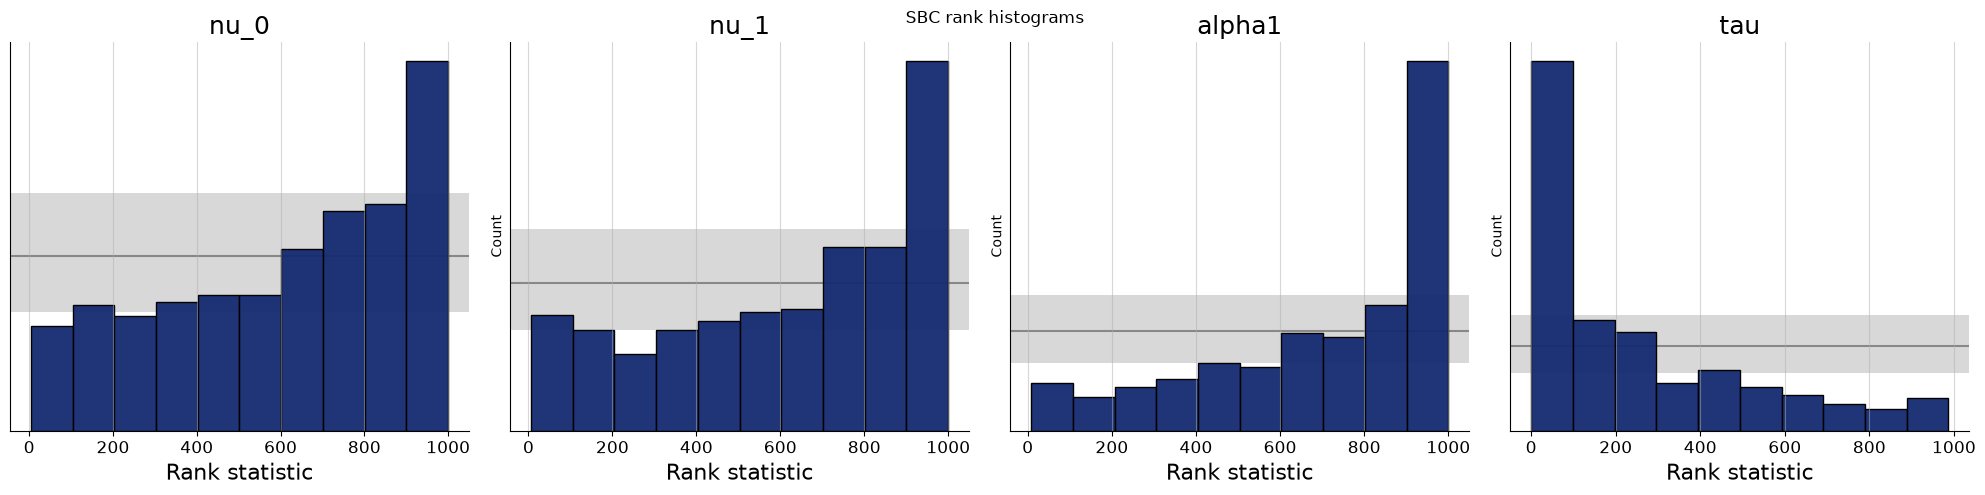

In [8]:
# TODO: calibration plots, SBC, posterior contraction using approximator.sample()
N_TEST = 500
test_data = simulator.sample(N_TEST)
N_POST_SAMPLES = 1000
posterior_draws = approximator.sample(conditions=test_data, num_samples=N_POST_SAMPLES)
f_sbc_hist = bf.diagnostics.plots.calibration_histogram(
    estimates=posterior_draws,
    targets=test_data,
    variable_keys=["nu", "alpha1", "tau"],
)
f_sbc_hist.suptitle("SBC rank histograms")
plt.show()

## 8. Real Data Fitting (Evans et al. 2020) - TODO, diagnostics pair

In [ ]:
# TODO: Fit the trained model to REAL data (Evans et al. 2020)

# 1. Load the real dataset. Expected per trial:
#    - a subject ID
#    - which accumulator won (correct)
#    - first response time
#    - whether a double response happened
#    - second response time (only meaningful if a double response happened)

# 2. Clean it:
#    - fill missing second_response_time with 0.0 where there was no double response
#    - group trials by subject

# 3. Reshape into our variable names: first_response_time, correct,
#    double_flag, second_response_time (same format simulate_dataset() produces)

# 4. Get posterior estimates per subject:
#    posterior_real = approximator.sample(conditions=real_data, num_samples=1000)

# 5. Posterior predictive check, per subject:
#    - take that subject's estimated parameters
#    - re-simulate fake data using simulate_dataset() with those estimates
#    - build two plots: one comparing simulated vs real first response times,
#      one comparing simulated vs real double-response times
#    - repeat for every subject

# 5b. Also plot the joint posterior (pairs_posterior) for at least one subject,
#     to visualize how their estimated parameters relate to each other

# 6. Build a summary table: one row per subject, with mean + uncertainty
#    range for nu, alpha1, tau - useful for the report/presentation

# 7. Compare final estimates across subjects to what Evans et al. (2020) reported